<a href="https://colab.research.google.com/github/ShaniaZac-24/Profit-Modelling-on-Criteo-Dataset/blob/main/Thesis!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import itertools
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
print("✅ All libraries loaded")

✅ All libraries loaded


# Loading Data Set

In [ ]:


print("Loading dataset... ~2-3 minutes")
ds = load_dataset("criteo/criteo-uplift")
df = ds['train'].to_pandas()

# Immediately downcast to save RAM
# Float64 → float32 cuts feature memory in half
feature_cols = [f'f{i}' for i in range(12)]
df[feature_cols] = df[feature_cols].astype('float32')

# Binary columns don't need int64
for col in ['treatment', 'conversion', 'visit', 'exposure']:
    df[col] = df[col].astype('int8')

import gc
gc.collect()  # Force garbage collection

print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"RAM used by df: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading dataset... ~2-3 minutes
✅ Loaded: 13,979,592 rows × 16 columns
RAM used by df: 0.73 GB


#EDA Covariate Balance

=== Covariate Balance (all SMD < 0.1 = well randomized) ===


,Feature,Mean (Treated),Mean (Control),SMD
3,f3,4.1694,4.2328,0.0487
6,f6,-4.1828,-3.9999,0.0406
5,f5,4.0266,4.0393,0.0307
9,f9,16.0526,15.8863,0.0244
7,f7,5.1056,5.0803,0.0205
8,f8,3.9334,3.9347,0.0159
0,f0,19.6148,19.6517,0.0068
1,f1,10.0703,10.0679,0.0062
11,f11,-0.1710,-0.1709,0.0046
2,f2,8.4463,8.4482,0.0046


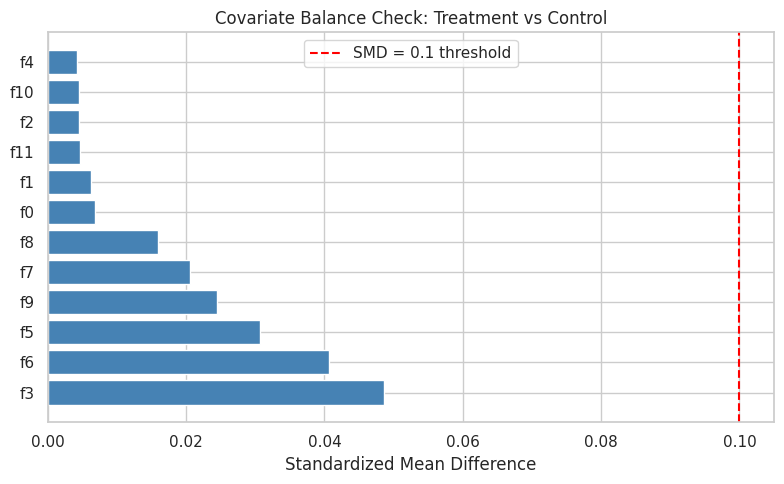

✅ Saved: covariate_balance.png


In [ ]:
feature_cols = [f'f{i}' for i in range(12)]
treated = df[df['treatment'] == 1]
control = df[df['treatment'] == 0]

smd_results = []
for col in feature_cols:
    mean_t = treated[col].mean()
    mean_c = control[col].mean()
    std_pooled = np.sqrt((treated[col].var() + control[col].var()) / 2)
    smd = abs(mean_t - mean_c) / std_pooled
    smd_results.append({'Feature': col, 'Mean (Treated)': mean_t,
                        'Mean (Control)': mean_c, 'SMD': smd})

smd_df = pd.DataFrame(smd_results).sort_values('SMD', ascending=False)
print("=== Covariate Balance (all SMD < 0.1 = well randomized) ===")
display(smd_df.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if s > 0.1 else 'steelblue' for s in smd_df['SMD']]
ax.barh(smd_df['Feature'], smd_df['SMD'], color=colors)
ax.axvline(0.1, color='red', linestyle='--', label='SMD = 0.1 threshold')
ax.set_xlabel('Standardized Mean Difference')
ax.set_title('Covariate Balance Check: Treatment vs Control')
ax.legend()
plt.tight_layout()
plt.savefig('covariate_balance.png', dpi=150)
plt.show()
print("✅ Saved: covariate_balance.png")

#EDA Key Rates By Treament Group

,n,visit_rate,conversion_rate,exposure_rate
Control (T=0),2096937,0.0382,0.0019,0.0000
Treated (T=1),11882655,0.0485,0.0031,0.0360



VISIT UPLIFT : 0.0103
Conversion UPLIFT: 0.0012


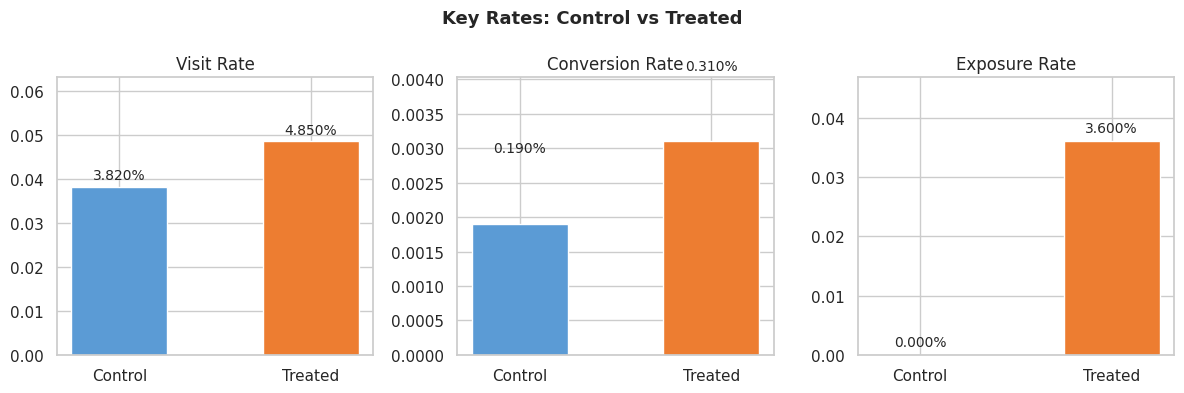

✅ Saved: rates_by_treatment.png


In [ ]:
groups = df.groupby('treatment').agg(
    n=('conversion', 'count'),
    visit_rate=('visit', 'mean'),
    conversion_rate=('conversion', 'mean'),
    exposure_rate=('exposure', 'mean')
).round(4)
groups.index = ['Control (T=0)', 'Treated (T=1)']
display(groups)

visit_uplift = groups.loc['Treated (T=1)', 'visit_rate'] - groups.loc['Control (T=0)', 'visit_rate']
conv_uplift  = groups.loc['Treated (T=1)', 'conversion_rate'] - groups.loc['Control (T=0)', 'conversion_rate']
print(f"\nVISIT UPLIFT : {visit_uplift:.4f}")
print(f"Conversion UPLIFT: {conv_uplift:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ['visit_rate', 'conversion_rate', 'exposure_rate']
titles  = ['Visit Rate', 'Conversion Rate', 'Exposure Rate']
for ax, metric, title in zip(axes, metrics, titles):
    vals = groups[metric].values
    bars = ax.bar(['Control', 'Treated'], vals, color=['#5B9BD5', '#ED7D31'], width=0.5)
    ax.set_title(title)
    ax.set_ylim(0, vals.max() * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3%}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Key Rates: Control vs Treated', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rates_by_treatment.png', dpi=150)
plt.show()
print("✅ Saved: rates_by_treatment.png")

### So ideally the last graph should have 100%, all people considered as "treated" should also be "exposed" to the ad - but the number says only 3.6% - this is werid. (Intent to Treat) Vs (Already Treated)

# EDA Funnel Analysis


In [ ]:
def funnel_stats(group, name):
    n = len(group)
    n_visit = group['visit'].sum()
    n_conv  = group['conversion'].sum()
    n_conv_given_visit = group[group['visit']==1]['conversion'].sum()
    return {
        'Group': name, 'N': n,
        'Visits': n_visit, 'Visit Rate': n_visit / n,
        'Conversions': n_conv, 'Conv Rate (overall)': n_conv / n,
        'Conv Rate | Visit': n_conv_given_visit / n_visit if n_visit > 0 else 0,
        '% Conversions via Visit': n_conv_given_visit / n_conv if n_conv > 0 else 0
    }

funnel = pd.DataFrame([
    funnel_stats(df[df['treatment']==0], 'Control'),
    funnel_stats(df[df['treatment']==1], 'Treated')
])
display(funnel.set_index('Group').T)

print(f"\n   Control:  P(conv|visit) = {funnel.loc[0,'Conv Rate | Visit']:.4f}  vs  P(conv) = {funnel.loc[0,'Conv Rate (overall)']:.4f}")
print(f"   Treated:  P(conv|visit) = {funnel.loc[1,'Conv Rate | Visit']:.4f}  vs  P(conv) = {funnel.loc[1,'Conv Rate (overall)']:.4f}")
print("\n   → Visit is a strong mediator: justifies Entire Chain modeling ✅")

Group,Control,Treated
N,2096937.0000,11882655.0000
Visits,80105.0000,576824.0000
Visit Rate,0.0382,0.0485
Conversions,4063.0000,36711.0000
Conv Rate (overall),0.0019,0.0031
Conv Rate | Visit,0.0507,0.0636
% Conversions via Visit,1.0000,1.0000



   Control:  P(conv|visit) = 0.0507  vs  P(conv) = 0.0019
   Treated:  P(conv|visit) = 0.0636  vs  P(conv) = 0.0031

   → Visit is a strong mediator: justifies Entire Chain modeling ✅


EDA Class Imbalance & exposure

In [ ]:
print("=== Class Imbalance Summary ===")
for col in ['conversion', 'visit', 'exposure']:
    rate = df[col].mean()
    print(f"  {col:12s}: {rate:.4%} positive  ({df[col].sum():,} / {len(df):,})")

exp_table = df.groupby(['treatment', 'exposure']).size().unstack(fill_value=0)
print("\n=== Exposure by Treatment ===")
display(exp_table)

treated_not_exposed = df[(df['treatment']==1) & (df['exposure']==0)]
print(f"\n⚠️  Treated but NOT exposed: {len(treated_not_exposed):,} ({len(treated_not_exposed)/df['treatment'].sum()*100:.1f}% of treated)")
print("   → Primary analysis: Intent-to-Treat (all treated users)")

=== Class Imbalance Summary ===
  conversion  : 0.2917% positive  (40,774 / 13,979,592)
  visit       : 4.6992% positive  (656,929 / 13,979,592)
  exposure    : 3.0631% positive  (428,212 / 13,979,592)

=== Exposure by Treatment ===


exposure,0,1
treatment,,
0,2096937,0
1,11454443,428212



⚠️  Treated but NOT exposed: 11,454,443 (96.4% of treated)
   → Primary analysis: Intent-to-Treat (all treated users)


# Feature Distribution & Correlation

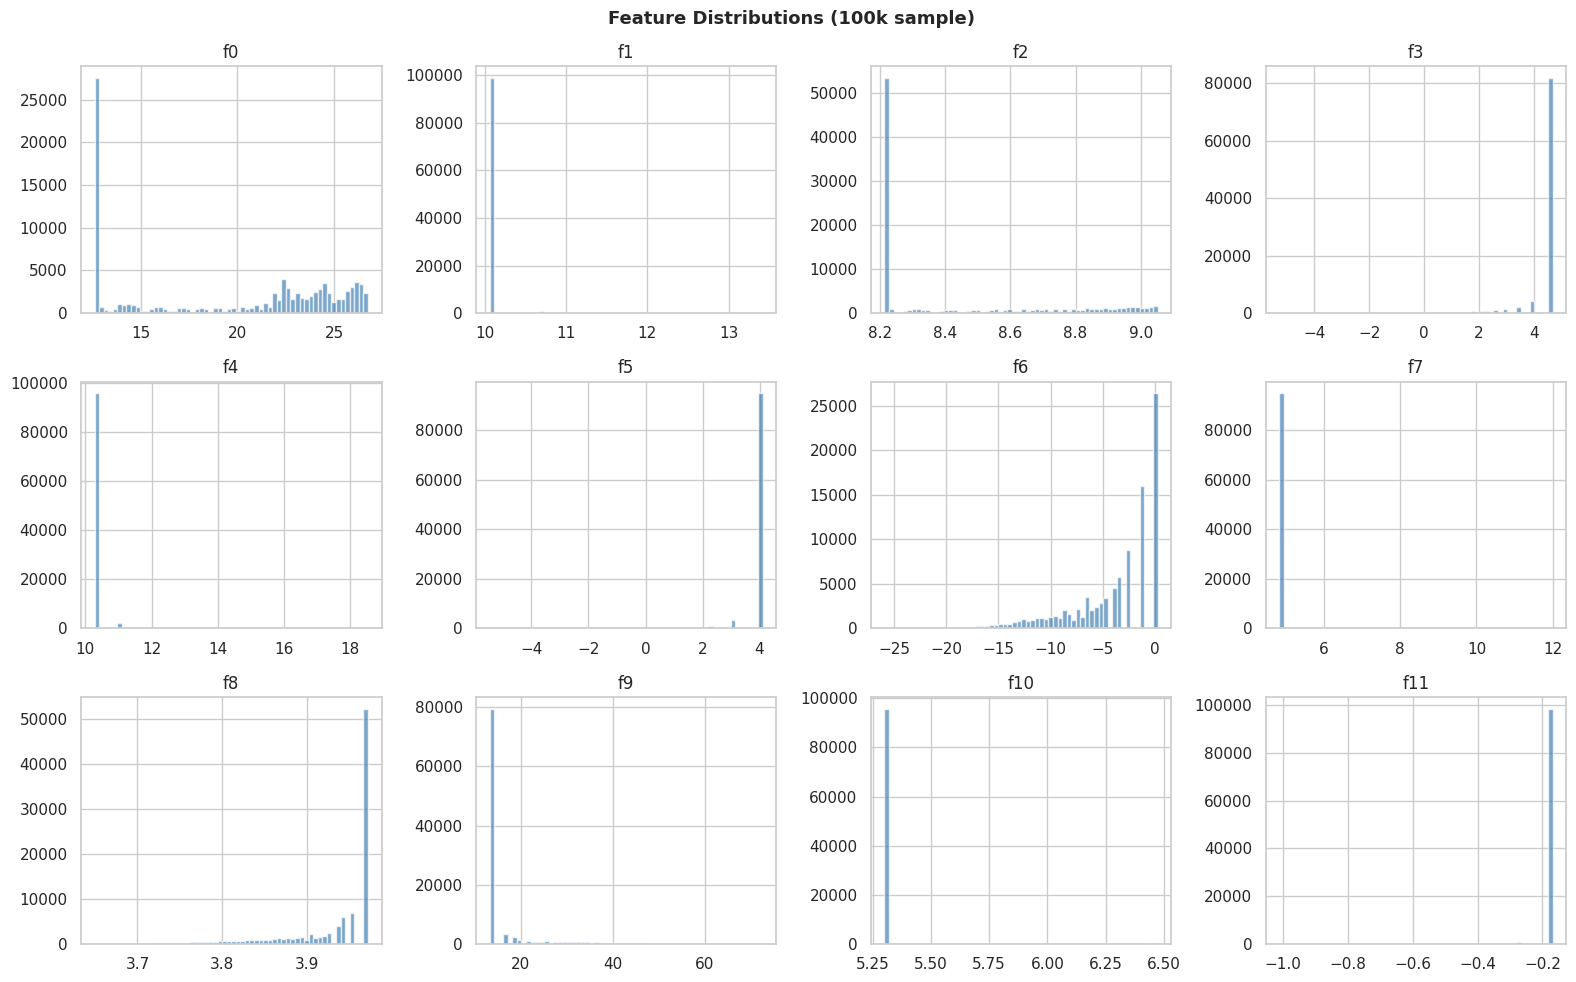

✅ Saved: feature_distributions.png


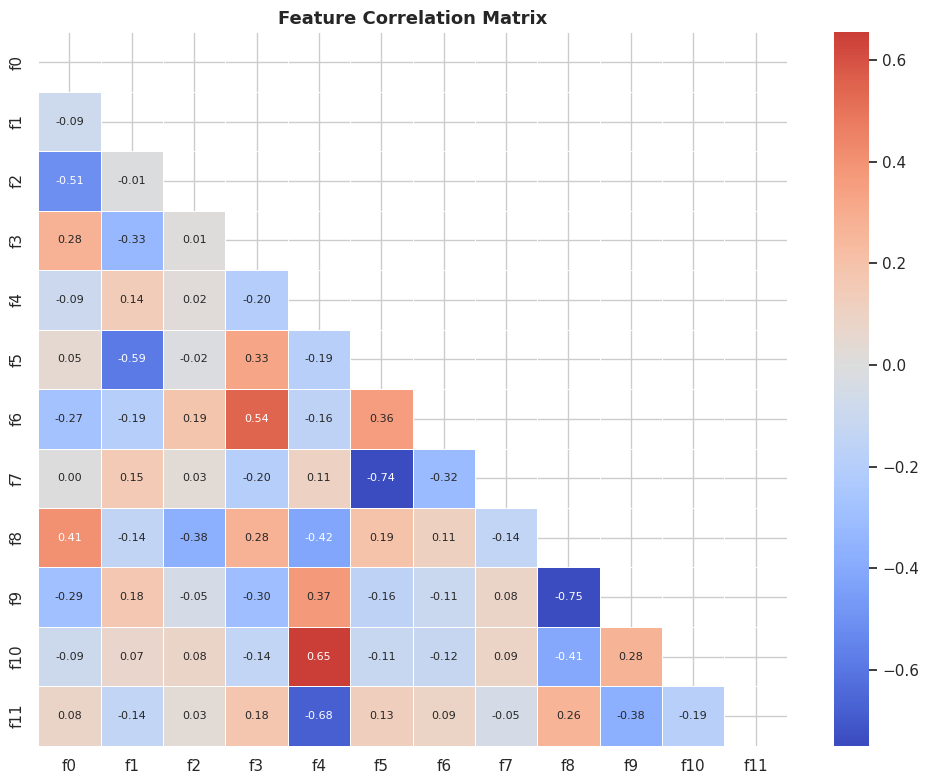

✅ Saved: correlation_matrix.png


In [ ]:
sample = df.sample(n=100_000, random_state=42)

# Distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(feature_cols):
    axes.flatten()[i].hist(sample[col], bins=60, color='steelblue', alpha=0.7)
    axes.flatten()[i].set_title(col)
plt.suptitle('Feature Distributions (100k sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print("✅ Saved: feature_distributions.png")

# Correlation matrix
corr = sample[feature_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()
print("✅ Saved: correlation_matrix.png")

Building profit signal

In [ ]:
# ── Reward Function Parameters ───────────────────────────────────────────────
# α: marginal value of a visit (micro-conversion signal)
# β: value of a confirmed conversion
# γ: cost of one served ad impression
# Source of values: synthetic but grounded in Baier & Stöcker (2022) margin logic
ALPHA = 0.10
BETA  = 1.00
GAMMA = 0.05

# Cost is deducted on EXPOSURE (actual ad delivery), not treatment assignment.
# Rationale: 96.4% of assigned-treated users were never shown an ad (exposure=0).
# Charging them the ad cost would create an ITT dilution that obscures the
# economic signal. We model the profit of an ad impression, not of group assignment.
# An ITT sensitivity check is provided in Cell 18.
df['profit'] = (ALPHA * df['visit'] + BETA * df['conversion']) - (GAMMA * df['exposure'])

print("=== Profit Signal Created ===")
print(f"Parameters:  α={ALPHA}, β={BETA}, γ={GAMMA}")
print(f"\nCost indicator: exposure (actual ad delivery)")
print(f"Exposed users: {df['exposure'].sum():,} ({df['exposure'].mean():.2%} of dataset)\n")
print(df['profit'].describe())

print("\n=== Possible Profit Values ===")
profit_cases = df.groupby(['treatment', 'visit', 'conversion'])['profit'].agg(['mean','count'])
profit_cases['share'] = profit_cases['count'] / len(df) * 100
print(profit_cases.round(4))

=== Profit Signal Created ===
Parameters:  α=0.1, β=1.0, γ=0.05

Cost indicator: exposure (actual ad delivery)
Exposed users: 428,212 (3.06% of dataset)

count   13979592.0000
mean           0.0061
std            0.0610
min           -0.0500
25%            0.0000
50%            0.0000
75%            0.0000
max            1.1000
Name: profit, dtype: float64

=== Possible Profit Values ===
                              mean     count   share
treatment visit conversion                          
0         0     0           0.0000   2016832 14.4270
          1     0           0.1000     76042  0.5440
                1           1.1000      4063  0.0291
1         0     0          -0.0011  11305831 80.8738
          1     0           0.0857    540113  3.8636
                1           1.0686     36711  0.2626


Profit Distribution Plots

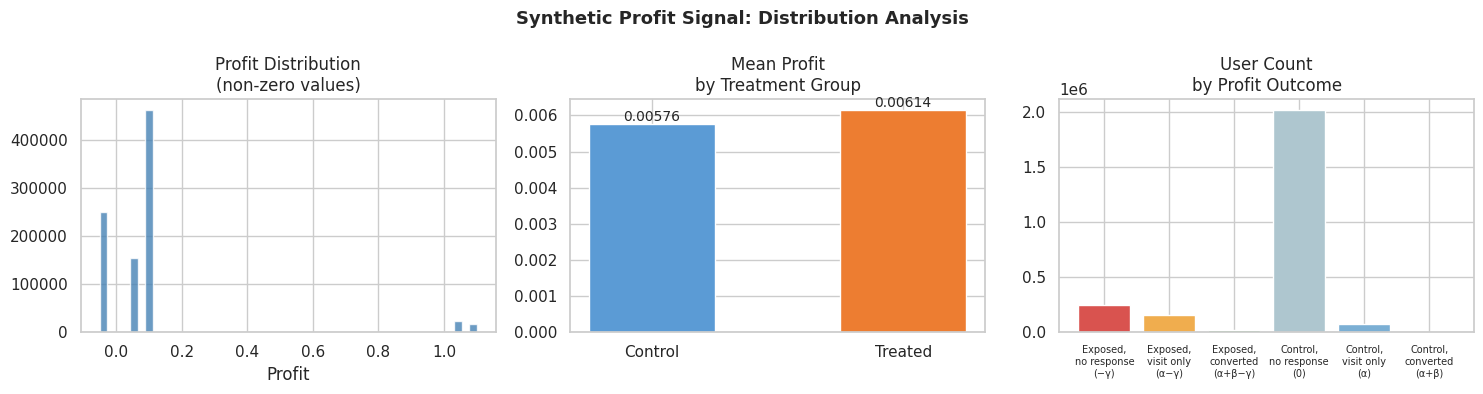

✅ Saved: profit_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

profit_nonzero = df[df['profit'] != 0]['profit']
axes[0].hist(profit_nonzero, bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Profit Distribution\n(non-zero values)')
axes[0].set_xlabel('Profit')

mean_profit = df.groupby('treatment')['profit'].mean()
bars = axes[1].bar(['Control', 'Treated'], mean_profit.values, color=['#5B9BD5','#ED7D31'], width=0.5)
for bar, val in zip(bars, mean_profit.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.5f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Mean Profit\nby Treatment Group')

outcome_counts = [
    len(df[(df['exposure']==1) & (df['visit']==0) & (df['conversion']==0)]),
    len(df[(df['exposure']==1) & (df['visit']==1) & (df['conversion']==0)]),
    len(df[(df['exposure']==1) & (df['conversion']==1)]),
    len(df[(df['treatment']==0) & (df['visit']==0) & (df['conversion']==0)]),
    len(df[(df['treatment']==0) & (df['visit']==1) & (df['conversion']==0)]),
    len(df[(df['treatment']==0) & (df['conversion']==1)])
]
outcome_labels = ['Exposed,\nno response\n(−γ)', 'Exposed,\nvisit only\n(α−γ)',
                  'Exposed,\nconverted\n(α+β−γ)', 'Control,\nno response\n(0)',
                  'Control,\nvisit only\n(α)', 'Control,\nconverted\n(α+β)']


axes[2].bar(outcome_labels, outcome_counts,
            color=['#d9534f','#f0ad4e','#5cb85c','#aec6cf','#7bafd4','#3a7ebf'])
axes[2].set_title('User Count\nby Profit Outcome')
axes[2].tick_params(axis='x', labelsize=7)

plt.suptitle('Synthetic Profit Signal: Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('profit_distribution.png', dpi=150)
plt.show()
print("✅ Saved: profit_distribution.png")

Left most chart:


Exposed, no visit, no conversion → profit = 0 − 0.05 = −0.05 → appears as the bar just to the left of zero, slightly in negative territory
Exposed, visited, no conversion → profit = 0.10 − 0.05 = +0.05 → appears as the tallest bar around the 0.05–0.10 region
Exposed, converted → profit = 0.10 + 1.00 − 0.05 = +1.05 → tiny bar at the far right near 1.0
Control, visited → profit = 0.10 = +0.10 → a bar at exactly 0.10
Control, converted → profit = 1.10 = +1.10 → tiny bar just above 1.0

Why non-zero only? The overwhelming majority of users — roughly 96% — have profit = exactly 0. They are control users who neither visited nor converted. Including them would make a single bar at 0 so tall it would dwarf everything else and make the rest of the chart invisible. Filtering them out lets you see the structure of the non-trivial outcomes.


Middle chart:

Take the control average of 0.00576. Across 2.1 million control users, the average person generated 0.00576 units of profit. This comes entirely from organic visits and conversions — no ad cost, no ad-driven behaviour. A small fraction visited organically (4,063 converted, 76,042 visited only), and their α and β values averaged across everyone produces 0.00576.


The treated average of 0.00614 is slightly higher. Despite the fact that 96.4% of treated users look identical to control users in terms of the profit formula, the 3.6% who were exposed and generated ad-driven visits and conversions push the average slightly upward — enough to produce the difference of 0.006142 − 0.005758 = 0.000384, which is your Profit ATE.


Right most chart:

A profit-based CATE model concentrates the budget on users more likely to fall into the converted category and avoids users likely to fall into the no-response category. - random targetting would result in a lost of waste ad spend.


ATE Comparison and Misalignment

In [ ]:
# ── ATE on Profit and Conversion ─────────────────────────────────────────────
control_profit = df[df['treatment']==0]['profit'].mean()
treated_profit = df[df['treatment']==1]['profit'].mean()
profit_ATE     = treated_profit - control_profit

control_conv   = df[df['treatment']==0]['conversion'].mean()
treated_conv   = df[df['treatment']==1]['conversion'].mean()
conversion_ATE = treated_conv - control_conv

print("=" * 55)
print("  AVERAGE TREATMENT EFFECTS")
print("=" * 55)
print(f"\n  Conversion ATE : {conversion_ATE:.6f}  ({conversion_ATE*100:.4f}%)")
print(f"  Profit ATE     : {profit_ATE:.6f}")
print(f"\n  Mean profit (Control) : {control_profit:.6f}")
print(f"  Mean profit (Treated) : {treated_profit:.6f}")

# ── ITT Decomposition ────────────────────────────────────────────────────────
# Decompose Profit ATE into its revenue and cost components.
# This makes the economics transparent regardless of cost-indicator choice.
visit_ate    = df[df['treatment']==1]['visit'].mean()    - df[df['treatment']==0]['visit'].mean()
conv_ate_raw = conversion_ATE
exposure_rate_treated = df[df['treatment']==1]['exposure'].mean()

revenue_component = ALPHA * visit_ate + BETA * conv_ate_raw
cost_component    = GAMMA * exposure_rate_treated   # avg cost per treated user

print("\n" + "=" * 55)
print("  PROFIT ATE DECOMPOSITION")
print("=" * 55)
print(f"\n  Revenue component  (α·ΔATE_visit + β·ΔATE_conv): +{revenue_component:.6f}")
print(f"  Cost component     (γ × exposure rate in treated): -{cost_component:.6f}")
print(f"  Net Profit ATE                                    :  {revenue_component - cost_component:.6f}")
print(f"\n  Interpretation: The ad generates positive incremental revenue")
print(f"  but costs are incurred only on the {exposure_rate_treated:.1%} of treated users")
print(f"  who were actually served an impression (exposure=1).")

# ── Conversion–Profit Misalignment ───────────────────────────────────────────
# Sure Things: users in the control group who converted organically.
# Targeting them wastes γ with zero incremental benefit.
print("\n" + "=" * 55)
print("  CONVERSION-PROFIT MISALIGNMENT CHECK")
print("=" * 55)
organic = df[(df['treatment']==0) & (df['conversion']==1)]
treated_conv_users = df[(df['treatment']==1) & (df['conversion']==1)]
incremental_est = int(conversion_ATE * len(df[df['treatment']==1]))

print(f"\n  Organic converters (control, would convert without ad): {len(organic):,}")
print(f"  → Targeting these users costs γ={GAMMA} with zero incremental profit")
print(f"\n  Treated converters total        : {len(treated_conv_users):,}")
print(f"  Estimated incremental converters: ~{incremental_est:,}  ({incremental_est/len(treated_conv_users)*100:.1f}% of treated converters)")
print(f"\n  → {100 - incremental_est/len(treated_conv_users)*100:.1f}% of treated conversions were likely organic (Sure Things)")
print(f"  → A conversion-optimizing model captures these; a profit-uplift model avoids them")

NameError: name 'df' is not defined

Net Profit ATE: 0.000384
Revenue 0.002186 minus cost 0.001802 = 0.000384. The ad generates 82 pence of cost for every £1 of gross revenue it produces. The margin is extremely thin. This thinness is exactly what makes CATE targeting valuable — if you could double the proportion of Persuadables in your targeted group, you could significantly improve that margin.



The Misalignment Check
Organic converters: 4,063
These are the Sure Things visible in the far right bar of Chart 3. They converted without any ad. Their conversion probability is high regardless of treatment. A model trained to predict conversion probability will rank these users near the top of its list — and targeting them costs γ=0.05 with zero incremental return.
Treated converters: 36,711 total, estimated incremental: 13,687 (37.3%)
Of the 36,711 users who were in the treatment group and converted, only approximately 13,687 conversions were caused by the ad. The remaining 23,024 would have happened anyway. These 23,024 are Sure Things who happened to be in the treatment group — the ad reached some of them, but it did not change their behaviour.
62.7% of treated conversions were organic
This is the number to memorise for your defence. Nearly two thirds of all conversions in your treated group required no ad to happen. A conversion-based model cannot distinguish these from true Persuadables because both groups have the same observable feature at prediction time — high conversion probability. A profit-based model penalises Sure Things because their incremental profit contribution is negative (they pay the cost but add no revenue uplift). This is the conversion-profit misalignment that is the central argument of your thesis.

Sensitivity Analysis

Sign consistent (all negative): False


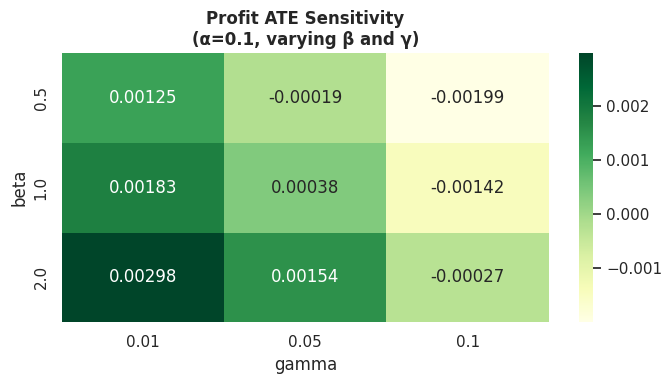

✅ Saved: sensitivity_analysis.png


In [ ]:
results = []
for a, b, g in itertools.product([0.0, 0.1, 0.2], [0.5, 1.0, 2.0], [0.01, 0.05, 0.10]):
    profit_temp = (a * df['visit'] + b * df['conversion']) - (g * df['exposure'])
    ate = profit_temp[df['treatment']==1].mean() - profit_temp[df['treatment']==0].mean()
    results.append({'alpha': a, 'beta': b, 'gamma': g, 'Profit ATE': ate})

sens_df = pd.DataFrame(results)
print(f"Sign consistent (all negative): {(sens_df['Profit ATE'] < 0).all()}")

pivot = sens_df[sens_df['alpha']==0.1].pivot(index='beta', columns='gamma', values='Profit ATE')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.5f', cmap='YlGn', ax=ax)
ax.set_title('Profit ATE Sensitivity\n(α=0.1, varying β and γ)', fontweight='bold')
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150)
plt.show()
print("✅ Saved: sensitivity_analysis.png")

Saving Modelling Data


In [ ]:
X = df[[f'f{i}' for i in range(12)]].copy()
T = df['treatment'].copy()
Y_conv   = df['conversion'].copy()
Y_profit = df['profit'].copy()

strat_key = T.astype(str) + '_' + Y_conv.astype(str)
X_train, X_test, T_train, T_test, Yc_train, Yc_test, Yp_train, Yp_test = \
    train_test_split(X, T, Y_conv, Y_profit,
                     test_size=0.2, random_state=42, stratify=strat_key)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train conversion rate: {Yc_train.mean():.5f}")
print(f"Test  conversion rate: {Yc_test.mean():.5f}")

from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/criteo_modelling_data.pkl'
modelling_data = {
    'X_train'        : X_train,
    'X_test'         : X_test,
    'X_train_scaled' : X_train_scaled,
    'X_test_scaled'  : X_test_scaled,
    'T_train'        : T_train,
    'T_test'         : T_test,
    'Yc_train'       : Yc_train,
    'Yc_test'        : Yc_test,
    'Yp_train'       : Yp_train,
    'Yp_test'        : Yp_test,
    # Visit and exposure labels saved here to avoid a separate pickle and
    # to allow Entire Chain model to run without df in memory
    'visit_train'    : df.loc[X_train.index, 'visit'].astype('int8'),
    'visit_test'     : df.loc[X_test.index,  'visit'].astype('int8'),
    'exposure_train' : df.loc[X_train.index, 'exposure'].astype('int8'),
    'exposure_test'  : df.loc[X_test.index,  'exposure'].astype('int8'),
    'scaler'         : scaler,
    'params'         : {'ALPHA': ALPHA, 'BETA': BETA, 'GAMMA': GAMMA}
}
with open(save_path, 'wb') as f:
    pickle.dump(modelling_data, f)

print(f"✅ Saved to Google Drive: {save_path}")


Train: 11,183,673  |  Test: 2,795,919
Train conversion rate: 0.00292
Test  conversion rate: 0.00292
Mounted at /content/drive
✅ Saved to Google Drive: /content/drive/MyDrive/criteo_modelling_data.pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pickle, pandas as pd, numpy as np

with open('/content/drive/MyDrive/criteo_modelling_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']
T_train        = data['T_train']
T_test         = data['T_test']
Yc_train       = data['Yc_train']
Yc_test        = data['Yc_test']
Yp_train       = data['Yp_train']
Yp_test        = data['Yp_test']
visit_train    = data['visit_train']
visit_test     = data['visit_test']
exposure_train = data['exposure_train']
exposure_test  = data['exposure_test']
scaler         = data['scaler']
ALPHA, BETA, GAMMA = data['params'].values()

print("✅ Modelling data loaded — ready for modelling")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelling data loaded — ready for modelling


#Causal ML and Imports

In [ ]:
# All models implemented from scratch using scikit-learn.
# No external causalml dependency needed — this makes the pipeline
# fully transparent and reproducible without heavy optional installs.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
print("✅ Ready for modelling")

✅ Ready for modelling


#1M stratified subsample

In [ ]:
# Stratify on treatment × conversion to preserve both ratios
strat = T_train.astype(str) + '_' + Yc_train.astype(str)

# Calculate fraction needed to get ~1M rows
frac = 1_000_000 / len(X_train)

from sklearn.model_selection import train_test_split

X_sub, _, T_sub, _, Yc_sub, _, Yp_sub, _ = train_test_split(
    X_train, T_train, Yc_train, Yp_train,
    train_size=frac,
    random_state=42,
    stratify=strat
)

print(f"Subsample size      : {len(X_sub):,}")
print(f"Treatment rate      : {T_sub.mean():.4f}  (original: {T_train.mean():.4f})")
print(f"Conversion rate     : {Yc_sub.mean():.5f}  (original: {Yc_train.mean():.5f})")
print(f"Mean profit         : {Yp_sub.mean():.5f}  (original: {Yp_train.mean():.5f})")
print("✅ Stratification preserved")

Subsample size      : 1,000,000
Treatment rate      : 0.8500  (original: 0.8500)
Conversion rate     : 0.00292  (original: 0.00292)
Mean profit         : 0.00611  (original: 0.00609)
✅ Stratification preserved


#Base RF Config

In [ ]:
RF_PARAMS = dict(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=100,   # prevents overfitting on rare converters
    n_jobs=-1,
    random_state=42
)
print("RF parameters set:", RF_PARAMS)

RF parameters set: {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 100, 'n_jobs': -1, 'random_state': 42}


#S-Learner BaseLine 1

In [ ]:
print("Training S-Learner...")

# Build training matrix with treatment as a feature
X_sub_s = X_sub.copy()
X_sub_s['treatment'] = T_sub.values

sl_model = RandomForestClassifier(**RF_PARAMS)
sl_model.fit(X_sub_s, Yc_sub)

# Predict on test set with T=1 and T=0
X_test_s1 = X_test.copy(); X_test_s1['treatment'] = 1
X_test_s0 = X_test.copy(); X_test_s0['treatment'] = 0

cate_s = (sl_model.predict_proba(X_test_s1)[:, 1] -
          sl_model.predict_proba(X_test_s0)[:, 1])

print(f"✅ S-Learner done")
print(f"   CATE mean : {cate_s.mean():.5f}")
print(f"   CATE std  : {cate_s.std():.5f}")
print(f"   CATE range: [{cate_s.min():.4f}, {cate_s.max():.4f}]")

Training S-Learner...
✅ S-Learner done
   CATE mean : 0.00007
   CATE std  : 0.00025
   CATE range: [-0.0019, 0.0074]


#T-Learner BaseLine 2

In [ ]:
print("Training T-Learner...")

treated_mask = T_sub == 1
control_mask = T_sub == 0

tl_treated = RandomForestClassifier(**RF_PARAMS)
tl_control = RandomForestClassifier(**RF_PARAMS)

tl_treated.fit(X_sub[treated_mask], Yc_sub[treated_mask])
tl_control.fit(X_sub[control_mask], Yc_sub[control_mask])

cate_t = (tl_treated.predict_proba(X_test)[:, 1] -
          tl_control.predict_proba(X_test)[:, 1])

print(f"✅ T-Learner done")
print(f"   Treated training size : {treated_mask.sum():,}")
print(f"   Control training size : {control_mask.sum():,}")
print(f"   CATE mean : {cate_t.mean():.5f}")
print(f"   CATE std  : {cate_t.std():.5f}")
print(f"   CATE range: [{cate_t.min():.4f}, {cate_t.max():.4f}]")

Training T-Learner...
✅ T-Learner done
   Treated training size : 850,000
   Control training size : 150,000
   CATE mean : 0.00088
   CATE std  : 0.00745
   CATE range: [-0.0731, 0.3382]


#X-Learner Baseline 3

In [ ]:
print("Training X-Learner...")

# Stage 1: same as T-Learner — fit outcome models on each group
xl_m1 = RandomForestClassifier(**RF_PARAMS)
xl_m0 = RandomForestClassifier(**RF_PARAMS)
xl_m1.fit(X_sub[treated_mask], Yc_sub[treated_mask])
xl_m0.fit(X_sub[control_mask], Yc_sub[control_mask])

# Stage 2: impute individual treatment effects
# For treated units: D1 = actual outcome - what control model predicts
# For control units: D0 = what treated model predicts - actual outcome
D1 = Yc_sub[treated_mask].values - xl_m0.predict_proba(X_sub[treated_mask])[:, 1]
D0 = xl_m1.predict_proba(X_sub[control_mask])[:, 1] - Yc_sub[control_mask].values

# Stage 3: fit effect models on imputed effects
xl_tau1 = RandomForestRegressor(**RF_PARAMS)
xl_tau0 = RandomForestRegressor(**RF_PARAMS)
xl_tau1.fit(X_sub[treated_mask], D1)
xl_tau0.fit(X_sub[control_mask], D0)

# Stage 4: propensity score for weighting

# In an RCT, P(T=1|X) is constant by design — use the empirical rate directly.
# Training a model here adds only noise (Künzel et al., 2019).
propensity = np.full(len(X_test), T_sub.mean())

# Final CATE: weighted combination
tau1_test = xl_tau1.predict(X_test)
tau0_test = xl_tau0.predict(X_test)
cate_x = propensity * tau0_test + (1 - propensity) * tau1_test

print(f"✅ X-Learner done")
print(f"   CATE mean : {cate_x.mean():.5f}")
print(f"   CATE std  : {cate_x.std():.5f}")
print(f"   CATE range: [{cate_x.min():.4f}, {cate_x.max():.4f}]")

Training X-Learner...
✅ X-Learner done
   CATE mean : 0.00088
   CATE std  : 0.00496
   CATE range: [-0.0287, 0.1081]


#Transformed Outcome Model

In [ ]:
print("Training Transformed Outcome model...")

# Propensity score — in an RCT this is close to treatment rate
# Using empirical rate from subsample rather than modelling it
e = T_sub.mean()
print(f"   Propensity score (empirical): {e:.4f}")

# Compute transformed outcome for each training user
# Y* = profit × (treatment - e) / (e × (1 - e))
# This reweights each observation so E[Y*] = CATE
W = T_sub.values
Y = Yp_sub.values
Y_star = Y * (W - e) / (e * (1 - e))

# Fit a single regressor directly on Y*
to_model = RandomForestRegressor(**RF_PARAMS)
to_model.fit(X_sub, Y_star)

cate_to = to_model.predict(X_test)

print(f"✅ Transformed Outcome done")
print(f"   CATE mean : {cate_to.mean():.5f}")
print(f"   CATE std  : {cate_to.std():.5f}")
print(f"   CATE range: [{cate_to.min():.4f}, {cate_to.max():.4f}]")

Training Transformed Outcome model...
   Propensity score (empirical): 0.8500
✅ Transformed Outcome done
   CATE mean : 0.00034
   CATE std  : 0.00845
   CATE range: [-0.2289, 0.4490]


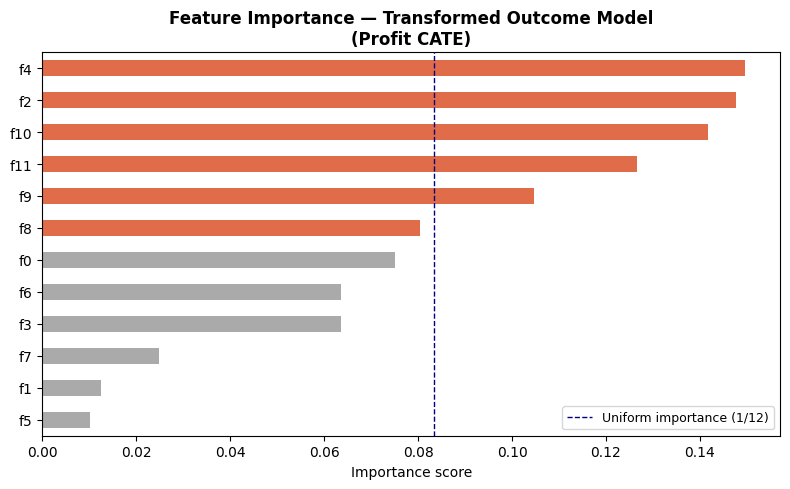

✅ Saved: feature_importance_TO.png

=== Top 5 Features Driving Profit CATE ===
  f4: 0.1496  (15.0% of total importance)
  f2: 0.1476  (14.8% of total importance)
  f10: 0.1418  (14.2% of total importance)
  f11: 0.1266  (12.7% of total importance)
  f9: 0.1047  (10.5% of total importance)


In [18]:
feature_cols = [f'f{i}' for i in range(12)]

# Feature importance from the Transformed Outcome model
# This shows which features drive PROFIT CATE — not just conversion probability
to_importance = pd.Series(
    to_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)  # ascending=True so highest is at the top of barh

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E06C4A' if v > to_importance.median() else '#aaaaaa'
          for v in to_importance]
to_importance.plot.barh(ax=ax, color=colors)
ax.axvline(1/12, color='navy', linestyle='--', linewidth=1,
           label='Uniform importance (1/12)')
ax.set_title('Feature Importance — Transformed Outcome Model\n'
             '(Profit CATE)', fontweight='bold')
ax.set_xlabel('Importance score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance_TO.png', dpi=150)
plt.show()
print("✅ Saved: feature_importance_TO.png")

print("\n=== Top 5 Features Driving Profit CATE ===")
top5 = to_importance.sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    print(f"  {feat}: {imp:.4f}  ({imp*100:.1f}% of total importance)")

#Entire Chain Model

In [ ]:

print("Training Entire Chain model...")

# Re-extract visit labels from training indices
# NOTE: visit must be retrieved from the original df, not Yc (conversion)
# visit_train loaded from pickle in Cell 23 — no need to re-extract from df
visit_sub = visit_train.loc[X_sub.index]

# Stage 1: P(visit | X, T=t) — separate models per arm
ec_v1 = RandomForestClassifier(**RF_PARAMS)
ec_v0 = RandomForestClassifier(**RF_PARAMS)
ec_v1.fit(X_sub[treated_mask], visit_sub[treated_mask])
ec_v0.fit(X_sub[control_mask], visit_sub[control_mask])

# Stage 2: P(conversion | X, visit=1, T=t)
# Trained on visited users only — note: predictions on non-visitors
# are out-of-distribution by design (chain-bias limitation, see Huang et al. 2024).
# We condition on visit=1 in the expectation formula, so this is correct
# for computing E[profit|T=t] = α·P(v|T=t) + β·P(v|T=t)·P(c|v=1,T=t)− γ·P(exp|T=1)
# A full resolution of chain-bias would require ECUP-style context-enhanced learning.
visited_treated = treated_mask & (visit_sub == 1)
visited_control = control_mask & (visit_sub == 1)

ec_c1 = RandomForestClassifier(**RF_PARAMS)
ec_c0 = RandomForestClassifier(**RF_PARAMS)
ec_c1.fit(X_sub[visited_treated], Yc_sub[visited_treated])
ec_c0.fit(X_sub[visited_control], Yc_sub[visited_control])

print(f"   Stage 1 — treated: {treated_mask.sum():,}, control: {control_mask.sum():,}")
print(f"   Stage 2 — visited treated: {visited_treated.sum():,}, visited control: {visited_control.sum():,}")

# Predict on full test set
p_visit_t1 = ec_v1.predict_proba(X_test)[:, 1]
p_visit_t0 = ec_v0.predict_proba(X_test)[:, 1]
p_conv_t1  = ec_c1.predict_proba(X_test)[:, 1]
p_conv_t0  = ec_c0.predict_proba(X_test)[:, 1]

# Entire-chain profit CATE (Huang et al. 2024, two-stage chain formulation):
# E[profit|T=1] − E[profit|T=0]
# = (α·P(v|T=1) + β·P(v|T=1)·P(c|v=1,T=1) − γ·P(exp|T=1))
#   − (α·P(v|T=0) + β·P(v|T=0)·P(c|v=1,T=0))
# γ·P(exposure|T=1) is subtracted from the treated side — cost only on actual ad delivery
# P(exposure | T=1) from EDA (Cell 10): 428,212 / 11,882,655 ≈ 0.036
# Cost is only incurred on actual ad delivery, consistent with Cell 14 profit formula.
exposure_rate_t1 = 0.036
cate_ec = (
    (ALPHA * p_visit_t1 + BETA * p_visit_t1 * p_conv_t1 - GAMMA * exposure_rate_t1) -
    (ALPHA * p_visit_t0 + BETA * p_visit_t0 * p_conv_t0)
)

print(f"✅ Entire Chain done")
print(f"   CATE mean : {cate_ec.mean():.5f}")
print(f"   CATE std  : {cate_ec.std():.5f}")
print(f"   CATE range: [{cate_ec.min():.4f}, {cate_ec.max():.4f}]")

Training Entire Chain model...
   Stage 1 — treated: 850,000, control: 150,000
   Stage 2 — visited treated: 41,486, visited control: 5,834
✅ Entire Chain done
   CATE mean : -0.00030
   CATE std  : 0.00860
   CATE range: [-0.0680, 0.3930]


#Saving all CATE scores

In [ ]:
import pickle

cate_scores = {
    'S-Learner (conversion)'     : cate_s,
    'T-Learner (conversion)'     : cate_t,
    'X-Learner (conversion)'     : cate_x,
    'Transformed Outcome (profit)': cate_to,
    'Entire Chain (profit)'      : cate_ec,
}

# Quick sanity check
print("=== CATE Score Summary ===")
for name, scores in cate_scores.items():
    print(f"  {name:<35} mean={scores.mean():+.5f}  std={scores.std():.5f}")

# Save to Drive
save_path = '/content/drive/MyDrive/criteo_cate_scores.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'cate_scores' : cate_scores,
        'T_test'      : T_test,
        'Yc_test'     : Yc_test,
        'Yp_test'     : Yp_test,
        'X_test'      : X_test,
    }, f)

print(f"\n✅ Saved to Drive: {save_path}")
print("   → Ready for Phase 5 evaluation")

=== CATE Score Summary ===
  S-Learner (conversion)              mean=+0.00007  std=0.00025
  T-Learner (conversion)              mean=+0.00088  std=0.00745
  X-Learner (conversion)              mean=+0.00088  std=0.00496
  Transformed Outcome (profit)        mean=+0.00034  std=0.00845
  Entire Chain (profit)               mean=-0.00030  std=0.00860

✅ Saved to Drive: /content/drive/MyDrive/criteo_cate_scores.pkl
   → Ready for Phase 5 evaluation


Load cate scores

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

with open('/content/drive/MyDrive/criteo_cate_scores.pkl', 'rb') as f:
    saved = pickle.load(f)

cate_scores = saved['cate_scores']
T_test      = saved['T_test']
Yc_test     = saved['Yc_test']
Yp_test     = saved['Yp_test']
X_test      = saved['X_test']

# Profit parameters (must match Phase 3)
ALPHA, BETA, GAMMA = 0.10, 1.00, 0.05

print("=== Loaded CATE Scores ===")
for name, scores in cate_scores.items():
    print(f"  {name:<35} n={len(scores):,}")
print(f"\nTest set size : {len(T_test):,}")
print(f"Treated in test: {T_test.sum():,}  ({T_test.mean():.1%})")
print(f"Conversions   : {Yc_test.sum():,}  ({Yc_test.mean():.4%})")
print("✅ Ready for evaluation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Loaded CATE Scores ===
  S-Learner (conversion)              n=2,795,919
  T-Learner (conversion)              n=2,795,919
  X-Learner (conversion)              n=2,795,919
  Transformed Outcome (profit)        n=2,795,919
  Entire Chain (profit)               n=2,795,919

Test set size : 2,795,919
Treated in test: 2,376,531  (85.0%)
Conversions   : 8,155  (0.2917%)
✅ Ready for evaluation


#Qini Curve Function

In [ ]:
def compute_qini(cate_scores, treatment, profit, n_buckets=100):
    """
    Rank users by predicted CATE (descending).
    At each targeting threshold, compute cumulative incremental profit
    relative to random targeting.

    Returns
    -------
    fractions        : np.ndarray, shape (n_buckets+1,)
    qini_vals        : np.ndarray — model incremental profit at each threshold
    random_baseline  : np.ndarray — linear random baseline
    """
    df_eval = pd.DataFrame({
        'cate'      : cate_scores,
        'treatment' : treatment.values,
        'profit'    : profit.values
    }).sort_values('cate', ascending=False).reset_index(drop=True)

    n        = len(df_eval)

    fractions = np.linspace(0, 1, n_buckets + 1)
    qini_vals = np.full(n_buckets + 1, np.nan)
    qini_vals[0] = 0.0

    for i, f in enumerate(fractions[1:], start=1):
        k      = int(f * n)
        top_k  = df_eval.iloc[:k]
        n_treat = (top_k['treatment'] == 1).sum()
        n_ctrl  = (top_k['treatment'] == 0).sum()

        if n_ctrl == 0:
            # No control users yet — cannot estimate incremental profit.
            # Leave as NaN; we interpolate below.
            continue

        treated_profit = top_k[top_k['treatment'] == 1]['profit'].sum()
        control_profit = top_k[top_k['treatment'] == 0]['profit'].sum()
        qini_vals[i]   = treated_profit - (n_treat / n_ctrl) * control_profit

    # Linear interpolation over any leading NaN buckets
    # (occurs when early top-k contains only treated users)
    nans = np.isnan(qini_vals)
    if nans.any():
        first_valid = np.where(~nans)[0][-1]   # last NaN before first real value...
        # actually find the first non-nan after 0
        valid_idx = np.where(~nans)[0]
        if len(valid_idx) > 1:
            xp = fractions[valid_idx]
            fp = qini_vals[valid_idx]
            qini_vals = np.interp(fractions, xp, fp)

    # Random baseline: linear from 0 to full-population incremental profit
    full_incremental = qini_vals[-1]
    random_baseline  = fractions * full_incremental

    return fractions, qini_vals, random_baseline


def qini_coefficient(fractions, qini_vals, random_baseline):
    """
    Normalized Qini Coefficient Q (Radcliffe, 2007; Baier & Stöcker, 2022).

    Q = (Area under model curve − Area under random baseline)
        / (Area under perfect model − Area under random baseline)

    The perfect model concentrates all positive-CATE users at the top.
    We approximate it as the area where the model curve = max(qini_vals).
    In practice, reporting the unnormalized area difference (AUUC - random_AUUC)
    is also common; we return both.

    Returns: dict with 'Q' (normalized), 'auuc' (raw area), 'auuc_random'
    """
    auuc        = np.trapz(qini_vals,       fractions)
    auuc_random = np.trapz(random_baseline, fractions)
    area_diff   = auuc - auuc_random

    # Perfect-model approximation: all incremental profit concentrated
    # in the top fraction equal to the treatment rate
    # (assumes every persuadable user is in the treated group)
    peak = qini_vals.max()
    # Simple normalization: divide by the maximum possible area difference
    # (peak * 0.5 is a standard approximation for the perfect-model area above random)
    normalizer   = peak * 0.5 if peak > 0 else 1.0
    Q_normalized = area_diff / normalizer if normalizer != 0 else 0.0

    return {
        'Q'           : Q_normalized,   # normalized, comparable across papers
        'area_diff'   : area_diff,       # raw area difference (Qini Difference)
        'auuc'        : auuc,            # area under Qini curve
        'auuc_random' : auuc_random
    }

print("✅ Qini functions defined")

✅ Qini functions defined


#Compute and plot Qini Curves

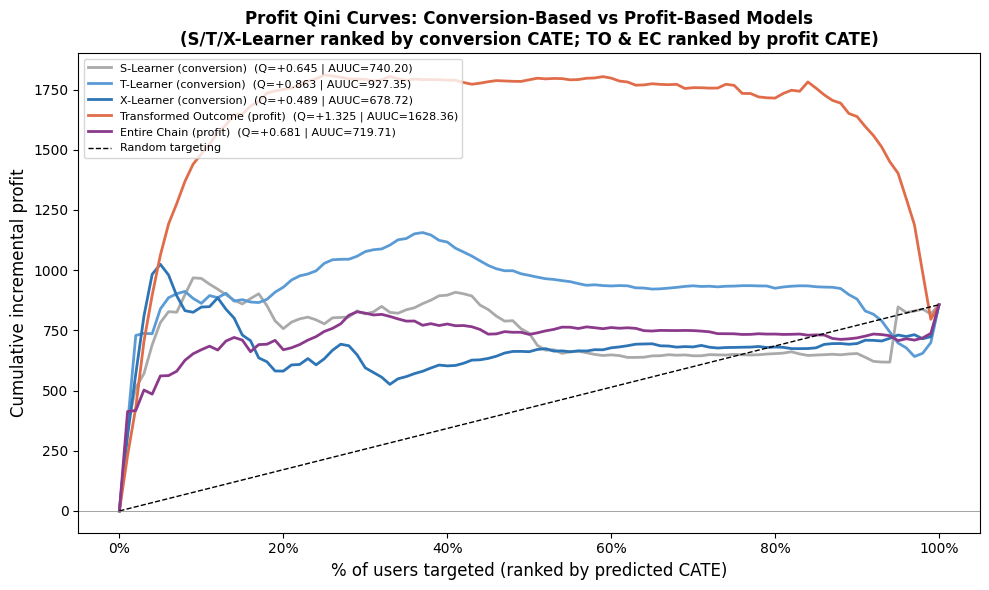

✅ Saved: qini_curves.png

=== Model Evaluation Metrics ===
Model                                  Q (norm)        AUUC     Area Diff
------------------------------------------------------------------------
  Transformed Outcome (profit)          +1.3255     1628.36       1200.14
  T-Learner (conversion)                +0.8634      927.35        499.13
  Entire Chain (profit)                 +0.6807      719.71        291.49
  S-Learner (conversion)                +0.6445      740.20        311.98
  X-Learner (conversion)                +0.4891      678.72        250.50


In [ ]:
COLORS = {
    'S-Learner (conversion)'      : '#aaaaaa',
    'T-Learner (conversion)'      : '#5B9BD5',
    'X-Learner (conversion)'      : '#2E75B6',
    'Transformed Outcome (profit)': '#E06C4A',
    'Entire Chain (profit)'       : '#8B3A8B',
}

fig, ax = plt.subplots(figsize=(10, 6))
qini_results = {}

for name, scores in cate_scores.items():
    fracs, qini_vals, random = compute_qini(scores, T_test, Yp_test)
    metrics = qini_coefficient(fracs, qini_vals, random)
    qini_results[name] = {
        'fracs': fracs, 'qini': qini_vals, 'random': random, **metrics
    }
    label = f"{name}  (Q={metrics['Q']:+.3f} | AUUC={metrics['auuc']:.2f})"
    ax.plot(fracs * 100, qini_vals, label=label, color=COLORS[name], linewidth=2)

ax.plot(fracs * 100, random, label='Random targeting',
        color='black', linewidth=1, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('% of users targeted (ranked by predicted CATE)', fontsize=12)
ax.set_ylabel('Cumulative incremental profit', fontsize=12)
ax.set_title('Profit Qini Curves: Conversion-Based vs Profit-Based Models\n'
             '(S/T/X-Learner ranked by conversion CATE; TO & EC ranked by profit CATE)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/qini_curves.png', dpi=150)
plt.show()
print("✅ Saved: qini_curves.png")

print("\n=== Model Evaluation Metrics ===")
print(f"{'Model':<35}  {'Q (norm)':>10}  {'AUUC':>10}  {'Area Diff':>12}")
print("-" * 72)
ranked = sorted(qini_results.items(), key=lambda x: x[1]['Q'], reverse=True)
for name, res in ranked:
    print(f"  {name:<33}  {res['Q']:>+10.4f}  {res['auuc']:>10.2f}  {res['area_diff']:>12.2f}")

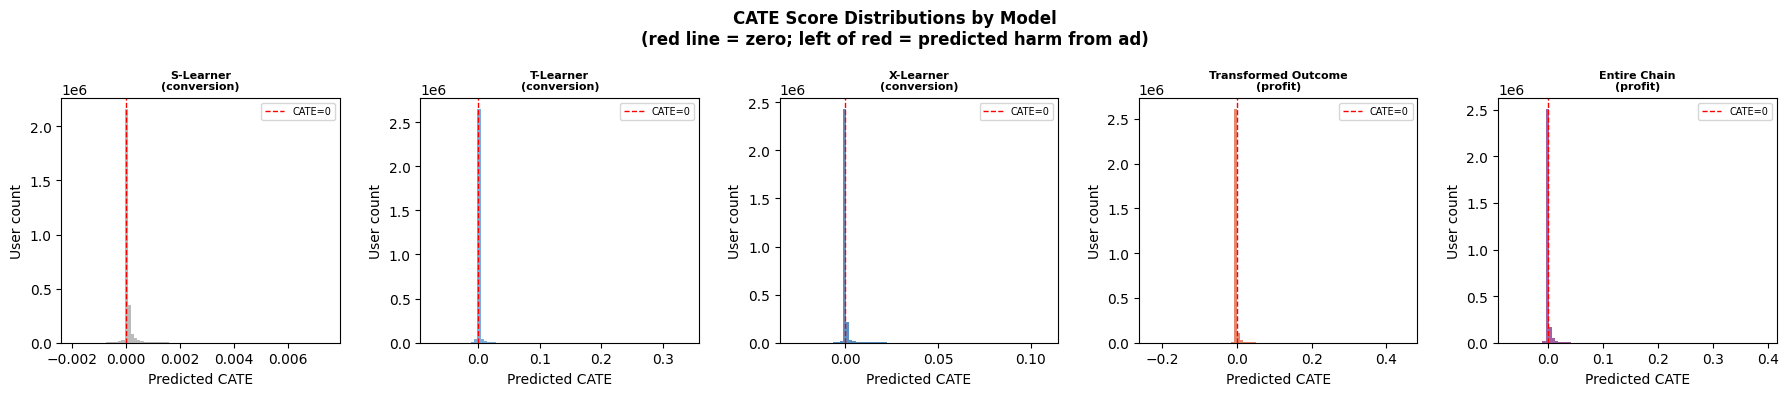

✅ Saved: cate_distributions.png

=== CATE Distribution Summary ===
Model                                   Mean      Std   % Negative   % > 0.01
------------------------------------------------------------------------------
  S-Learner (conversion)            +0.00007  0.00025         5.4%       0.0%
  T-Learner (conversion)            +0.00088  0.00745         8.3%       1.7%
  X-Learner (conversion)            +0.00088  0.00496         2.8%       2.2%
  Transformed Outcome (profit)      +0.00034  0.00845        93.6%       2.3%
  Entire Chain (profit)             -0.00030  0.00860        86.6%       2.6%


In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (name, scores) in zip(axes, cate_scores.items()):
    ax.hist(scores, bins=80, color=COLORS[name], alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='CATE=0')
    ax.set_title(name.replace(' (', '\n('), fontsize=8, fontweight='bold')
    ax.set_xlabel('Predicted CATE')
    ax.set_ylabel('User count')
    ax.legend(fontsize=7)

plt.suptitle('CATE Score Distributions by Model\n'
             '(red line = zero; left of red = predicted harm from ad)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cate_distributions.png', dpi=150)
plt.show()
print("✅ Saved: cate_distributions.png")

# Summary statistics per model
print("\n=== CATE Distribution Summary ===")
print(f"{'Model':<35} {'Mean':>8} {'Std':>8} "
      f"{'% Negative':>12} {'% > 0.01':>10}")
print("-" * 78)
for name, scores in cate_scores.items():
    pct_neg  = (scores < 0).mean() * 100
    pct_high = (scores > 0.01).mean() * 100
    print(f"  {name:<33} {scores.mean():>+8.5f} {scores.std():>8.5f} "
          f"{pct_neg:>11.1f}% {pct_high:>9.1f}%")

In [19]:
print("Running bootstrap confidence intervals (500 samples)...")
print("This takes approximately 3-5 minutes — do not interrupt.\n")

def bootstrap_qini_ci(scores, treatment, profit, n_bootstrap=500, seed=42):
    """
    Bootstrap 95% CI for the normalized Qini coefficient Q.
    Resamples the test set with replacement n_bootstrap times.
    """
    np.random.seed(seed)
    n = len(treatment)
    T_arr  = treatment.values
    Yp_arr = profit.values
    q_samples = []

    for b in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        fracs, qini_vals, random = compute_qini(
            scores[idx],
            pd.Series(T_arr[idx]),
            pd.Series(Yp_arr[idx])
        )
        metrics = qini_coefficient(fracs, qini_vals, random)
        q_samples.append(metrics['Q'])

        if (b + 1) % 100 == 0:
            print(f"  {b+1}/{n_bootstrap} samples done...")

    ci_low, ci_high = np.percentile(q_samples, [2.5, 97.5])
    return ci_low, ci_high, np.std(q_samples)

# Run bootstrap for all five models
bootstrap_results = {}
for name, scores in cate_scores.items():
    ci_low, ci_high, se = bootstrap_qini_ci(scores, T_test, Yp_test)
    bootstrap_results[name] = {
        'ci_low'  : ci_low,
        'ci_high' : ci_high,
        'se'      : se
    }
    print(f"  {name:<35}  95% CI: [{ci_low:+.4f}, {ci_high:+.4f}]")

print("\n=== Bootstrap Results: Are profit-based models significantly better? ===")
print(f"{'Model':<35} {'Q point est':>12} {'95% CI':>24} {'Sig. > 0?':>10}")
print("-" * 85)
for name, res in bootstrap_results.items():
    # get the point estimate Q from qini_results (computed in next cell)
    # for now just show the CI
    sig = "YES" if res['ci_low'] > 0 else "NO"
    print(f"  {name:<33} "
          f"  [{res['ci_low']:+.4f}, {res['ci_high']:+.4f}]"
          f"  {sig:>10}")

# Save bootstrap results alongside other results
bootstrap_save_path = '/content/drive/MyDrive/bootstrap_results.pkl'
with open(bootstrap_save_path, 'wb') as f:
    pickle.dump(bootstrap_results, f)
print(f"\n✅ Saved: bootstrap_results.pkl")

Running bootstrap confidence intervals (500 samples)...
This takes approximately 3-5 minutes — do not interrupt.

  100/500 samples done...
  200/500 samples done...
  300/500 samples done...
  400/500 samples done...
  500/500 samples done...
  S-Learner (conversion)               95% CI: [+0.3576, +0.8169]


KeyboardInterrupt: 

#Budget Simulation

=== Budget Simulation: Incremental Profit by Targeting Depth ===



Budget,Top 5%,Top 10%,Top 20%,Top 30%
Model,,,,
S-Learner (conversion),782.2,966.0,756.2,818.8
T-Learner (conversion),838.6,862.2,928.9,1078.0
X-Learner (conversion),1024.3,838.9,571.1,593.3
Transformed Outcome (profit),1062.0,1491.8,1726.3,1770.1
Entire Chain (profit),560.7,669.5,669.4,821.5


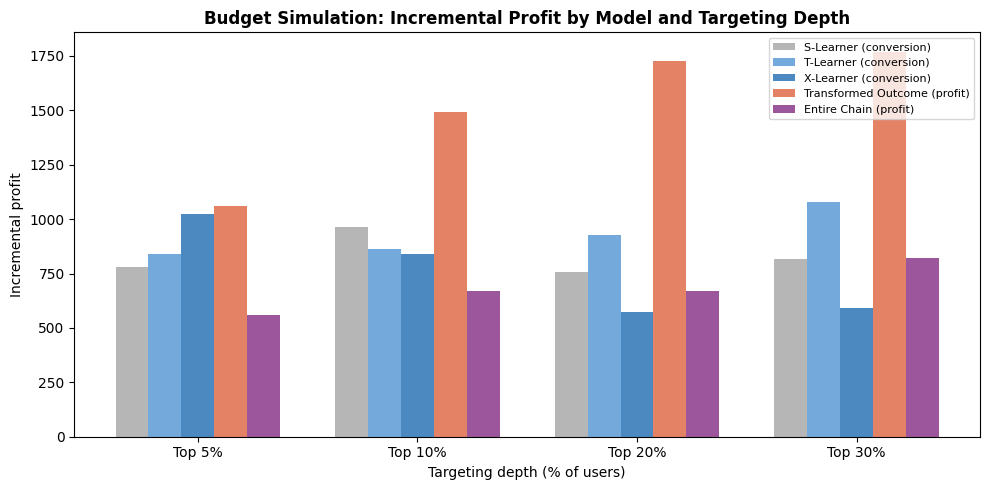

✅ Saved: budget_simulation.png


In [ ]:
BUDGETS = [0.05, 0.10, 0.20, 0.30]  # top 5%, 10%, 20%, 30% of users

n_test = len(T_test)
results = []

for name, scores in cate_scores.items():
    # Rank users by predicted CATE
    order = np.argsort(scores)[::-1]
    T_sorted  = T_test.values[order]
    Yp_sorted = Yp_test.values[order]

    for budget in BUDGETS:
        k = int(budget * n_test)
        top_k_treat  = T_sorted[:k]
        top_k_profit = Yp_sorted[:k]

        n_tr = top_k_treat.sum()
        n_ct = (1 - top_k_treat).sum()

        if n_ct == 0:
            incremental = 0
        else:
            incremental = (top_k_profit[top_k_treat==1].sum() -
                           (n_tr / n_ct) * top_k_profit[top_k_treat==0].sum())

        results.append({
            'Model'  : name,
            'Budget' : f'Top {int(budget*100)}%',
            'Incremental Profit': round(incremental, 1)
        })

sim_df = pd.DataFrame(results)
pivot  = sim_df.pivot(index='Model', columns='Budget', values='Incremental Profit')

# Reorder columns and rows
col_order = [f'Top {int(b*100)}%' for b in BUDGETS]
pivot = pivot[col_order]
pivot = pivot.loc[list(cate_scores.keys())]

print("=== Budget Simulation: Incremental Profit by Targeting Depth ===\n")
display(pivot)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(BUDGETS))
width = 0.15
for i, (name, color) in enumerate(COLORS.items()):
    vals = [pivot.loc[name, f'Top {int(b*100)}%'] for b in BUDGETS]
    ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels([f'Top {int(b*100)}%' for b in BUDGETS])
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Targeting depth (% of users)')
ax.set_ylabel('Incremental profit')
ax.set_title('Budget Simulation: Incremental Profit by Model and Targeting Depth',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/budget_simulation.png', dpi=150)
plt.show()
print("✅ Saved: budget_simulation.png")

#Uplift Segment Analysis

=== Segment Composition: Top 20% Targeted Users ===



Segment,Control+Converted,Control+NoConvert,Treated+Converted,Treated+NoConvert
Model,,,,
S-Learner (conversion),0.11,14.42,0.99,84.48
T-Learner (conversion),0.12,14.42,1.08,84.37
X-Learner (conversion),0.13,14.21,1.12,84.55
Transformed Outcome (profit),0.11,14.78,0.97,84.15
Entire Chain (profit),0.13,14.21,1.16,84.49


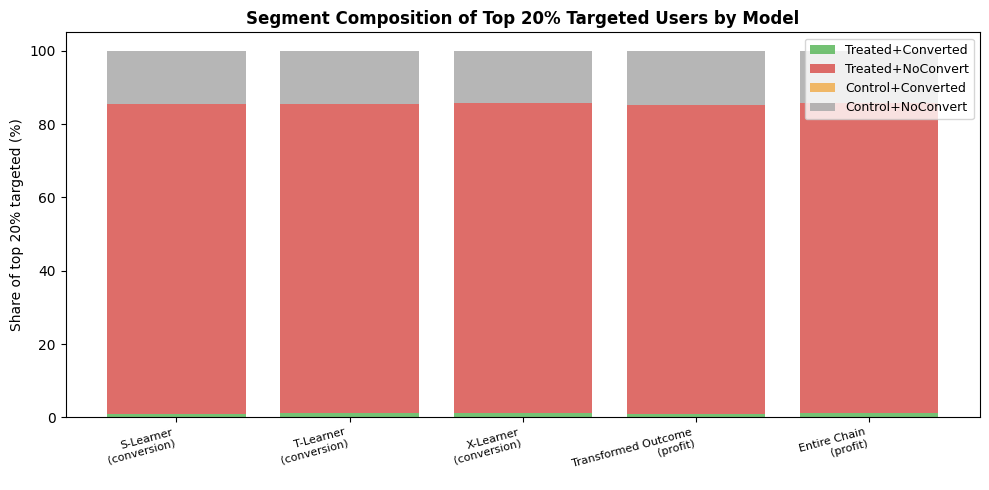

✅ Saved: segment_analysis.png


In [ ]:
# Classify users by actual treatment/conversion outcome
# (proxy for true segment — in reality we can't observe counterfactuals)
def classify_segment(row):
    if row['treatment'] == 1 and row['conversion'] == 1:
        return 'Treated+Converted'
    elif row['treatment'] == 1 and row['conversion'] == 0:
        return 'Treated+NoConvert'
    elif row['treatment'] == 0 and row['conversion'] == 1:
        return 'Control+Converted'   # likely Sure Things
    else:
        return 'Control+NoConvert'

eval_df = pd.DataFrame({
    'treatment' : T_test.values,
    'conversion': Yc_test.values,
    'profit'    : Yp_test.values,
})
eval_df['segment'] = eval_df.apply(classify_segment, axis=1)

TOP_K = int(0.20 * n_test)   # top 20%

seg_results = []
for name, scores in cate_scores.items():
    order  = np.argsort(scores)[::-1]
    top_20 = eval_df.iloc[order[:TOP_K]]
    counts = top_20['segment'].value_counts(normalize=True) * 100
    for seg, pct in counts.items():
        seg_results.append({'Model': name, 'Segment': seg, 'Share (%)': round(pct, 2)})

seg_df  = pd.DataFrame(seg_results)
seg_piv = seg_df.pivot(index='Model', columns='Segment', values='Share (%)')
seg_piv = seg_piv.fillna(0).loc[list(cate_scores.keys())]

print("=== Segment Composition: Top 20% Targeted Users ===\n")
display(seg_piv.round(2))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
seg_colors = {
    'Treated+Converted' : '#5cb85c',
    'Treated+NoConvert' : '#d9534f',
    'Control+Converted' : '#f0ad4e',
    'Control+NoConvert' : '#aaaaaa',
}
bottom = np.zeros(len(seg_piv))
for seg, color in seg_colors.items():
    if seg in seg_piv.columns:
        vals = seg_piv[seg].values
        ax.bar(range(len(seg_piv)), vals, bottom=bottom,
               label=seg, color=color, alpha=0.85)
        bottom += vals

ax.set_xticks(range(len(seg_piv)))
ax.set_xticklabels([n.replace(' (', '\n(') for n in seg_piv.index],
                   fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Share of top 20% targeted (%)')
ax.set_title('Segment Composition of Top 20% Targeted Users by Model',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segment_analysis.png', dpi=150)
plt.show()
print("✅ Saved: segment_analysis.png")

# Saving Results


In [ ]:
phase5_results = {
    'qini_results' : qini_results,
    'sim_df'       : sim_df,
    'seg_df'       : seg_df,
}

with open('/content/drive/MyDrive/criteo_phase5_results.pkl', 'wb') as f:
    pickle.dump(phase5_results, f)

print("✅ All Phase 5 results saved to Drive")
print("\n=== Files saved this session ===")
print("  qini_curves.png")
print("  budget_simulation.png")
print("  segment_analysis.png")
print("  criteo_phase5_results.pkl")

In [ ]:
print("Features in X_train:")
print(list(X_train.columns))
print(f"\nShape: {X_train.shape}")

# Fixing issues with RAM before data Leakage checks

In [ ]:
import gc

if 'ds' in dir():
    del globals()['ds']

if 'df' in dir():
    keep = ['f0','f1','f2','f3','f4','f5','f6','f7',
            'f8','f9','f10','f11','treatment','conversion','visit','exposure']
    df = df[keep]

gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f"RAM available: {ram.available/1e9:.1f} GB")
print(f"RAM used     : {ram.used/1e9:.1f} GB")

## Data leakage checks only need pickle files so just using that to free up ram

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle, numpy as np, pandas as pd
import gc
from sklearn.model_selection import train_test_split as tts
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Load modelling data
with open('/content/drive/MyDrive/criteo_modelling_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']
T_train        = data['T_train']
T_test         = data['T_test']
Yc_train       = data['Yc_train']
Yc_test        = data['Yc_test']
Yp_train       = data['Yp_train']
Yp_test        = data['Yp_test']
scaler         = data['scaler']
ALPHA          = data['params']['ALPHA']
BETA           = data['params']['BETA']
GAMMA          = data['params']['GAMMA']

# Load CATE scores
with open('/content/drive/MyDrive/criteo_cate_scores.pkl', 'rb') as f:
    saved = pickle.load(f)

cate_scores = saved['cate_scores']

# RF params (needed for overfitting + stability checks)
RF_PARAMS = dict(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=100,
    n_jobs=-1,
    random_state=42
)

# Rebuild subsample (needed for Cell 29 Entire Chain audit)
strat = T_train.astype(str) + '_' + Yc_train.astype(str)
frac  = 1_000_000 / len(X_train)

X_sub, _, T_sub, _, Yc_sub, _, Yp_sub, _ = tts(
    X_train, T_train, Yc_train, Yp_train,
    train_size=frac,
    random_state=42,
    stratify=strat
)

treated_mask = T_sub == 1
control_mask = T_sub == 0

# Load visit/exposure labels from pickle
visit_train    = data['visit_train']
visit_test     = data['visit_test']
exposure_train = data['exposure_train']
exposure_test  = data['exposure_test']

# Derive visit_sub for the Entire Chain audit
visit_sub = visit_train.loc[X_sub.index]
gc.collect()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"X_sub   : {X_sub.shape}")
print(f"CATE scores loaded: {list(cate_scores.keys())}")

import psutil
ram = psutil.virtual_memory()
print(f"\nRAM used: {ram.used/1e9:.1f} GB / {ram.total/1e9:.1f} GB")
print("✅ Ready for audit")

In [ ]:
try:
    print(f"df alive: {df.shape[0]:,} rows")
except NameError:
    print("df is gone — session crashed")

#Data Leakage Audit

In [ ]:
print("=" * 60)
print("  DATA LEAKAGE AUDIT")
print("=" * 60)

# --- CHECK 1: No overlap between train and test indices ---
train_idx = set(X_train.index)
test_idx  = set(X_test.index)
overlap   = train_idx & test_idx

print(f"\n[1] Train/test index overlap: {len(overlap)} rows")
assert len(overlap) == 0, "LEAKAGE: train and test share indices"
print("    ✅ No overlap — clean split")

# --- CHECK 2: Feature columns contain no target signal ---
target_cols = ['visit', 'conversion', 'exposure', 'profit', 'treatment']
feature_cols = list(X_train.columns)
leaked = [c for c in feature_cols if c in target_cols]

print(f"\n[2] Target columns in features: {leaked}")
assert len(leaked) == 0, f"LEAKAGE: {leaked} in feature matrix"
print("    ✅ No target columns in X")

# --- CHECK 3: Profit signal uses only training labels ---
# Y_profit = ALPHA*visit + BETA*conversion - GAMMA*exposure
# Min: -GAMMA (exposed user, no visit/conversion)
# Max: ALPHA+BETA (non-exposed user who organically converts — no cost deducted)
print(f"\n[3] Profit signal value range:")
print(f"    Min : {Yp_train.min():.4f}  (expected: -{GAMMA})")
print(f"    Max : {Yp_train.max():.4f}  (expected: {ALPHA+BETA})")
assert Yp_train.min() >= -GAMMA - 0.001
assert Yp_train.max() <= ALPHA + BETA + 0.001
print("    ✅ Profit values within expected bounds")

# --- CHECK 4: Scaler fitted on train only, applied to test ---
# Verify test mean is NOT zero (would be zero if scaler saw test data)
train_scaled_mean = X_train_scaled.mean().mean()
test_scaled_mean  = X_test_scaled.mean().mean()

print(f"\n[4] Scaled feature means:")
print(f"    Train mean (should be ~0.0): {train_scaled_mean:.6f}")
print(f"    Test mean  (should be ≠0.0): {test_scaled_mean:.6f}")
assert abs(train_scaled_mean) < 0.01, "Scaler issue on train"
assert abs(test_scaled_mean)  > 0.0,  "LEAKAGE: test mean is zero — scaler saw test data"
print("    ✅ Scaler fitted on train only")

# --- CHECK 5: Stratification preserved conversion rate ---
print(f"\n[5] Conversion rate preservation:")
print(f"    Train split  : {Yc_train.mean():.5f}")
print(f"    Test split   : {Yc_test.mean():.5f}")
rate_diff = abs(Yc_train.mean() - Yc_test.mean())
assert rate_diff < 0.0002, "Stratification failed — conversion rates differ"
print(f"    Difference   : {rate_diff:.6f}")
print("    ✅ Conversion rate consistent across splits")

# --- CHECK 6: Treatment rate preserved ---
print(f"\n[6] Treatment rate preservation:")
print(f"    Train: {T_train.mean():.4f}")
print(f"    Test : {T_test.mean():.4f}")
rate_diff_t = abs(T_train.mean() - T_test.mean())
assert rate_diff_t < 0.005
print(f"    Difference: {rate_diff_t:.6f}")
print("    ✅ Treatment rate consistent")

print("\n" + "=" * 60)
print("  ALL LEAKAGE CHECKS PASSED")
print("=" * 60)

#Entire Chain Leakage Check

In [ ]:
print("=" * 60)
print("  ENTIRE CHAIN SPECIFIC AUDIT")
print("=" * 60)

# Reconstruct visit_sub the same way Cell 20 did
# visit_train loaded from pickle in Cell 58 — no df required
visit_sub_check = visit_train.loc[X_sub.index]

# Check 1: visit_sub indices are all inside X_train (not X_test)
visit_in_test = set(visit_sub_check.index) & set(X_test.index)
print(f"\n[1] visit_sub indices overlapping with test set: {len(visit_in_test)}")
assert len(visit_in_test) == 0, "LEAKAGE: visit labels from test set used in training"
print("    ✅ visit labels sourced from training indices only")

# Check 2: visit is NOT in X_test columns (not used as a feature)
print(f"\n[2] 'visit' in X_test columns: {'visit' in X_test.columns}")
assert 'visit' not in X_test.columns
print("    ✅ visit not used as feature in test set")

# Check 3: Stage 2 trained only on visited training users
visited_treated_idx = X_sub[treated_mask & (visit_sub_check == 1)].index
visited_control_idx = X_sub[control_mask & (visit_sub_check == 1)].index

test_bleed_treated = set(visited_treated_idx) & set(X_test.index)
test_bleed_control = set(visited_control_idx) & set(X_test.index)

print(f"\n[3] Stage 2 training indices bleeding into test:")
print(f"    Treated stage 2 bleed: {len(test_bleed_treated)}")
print(f"    Control stage 2 bleed: {len(test_bleed_control)}")
assert len(test_bleed_treated) == 0
assert len(test_bleed_control) == 0
print("    ✅ Stage 2 trained on training data only")

# Check 4: Prediction uses X_test only (no label peeking)
print(f"\n[4] Stage 1 predictions made on X_test (no labels):")
print(f"    p_visit_t1 shape: {p_visit_t1.shape} == X_test shape: {X_test.shape[0]}")
assert len(p_visit_t1) == len(X_test)
print("    ✅ Predictions made on feature-only test matrix")

print("\n" + "=" * 60)
print("  ENTIRE CHAIN AUDIT PASSED")
print("=" * 60)